# P12. Dynamic Liquid Layers

A liquid layer can be solved two ways. The **static** form (Saito 1974) drops the liquid's inertia and treats it as hydrostatic, which is accurate at the long periods of most tides. The **dynamic** form (Takeuchi and Saito 1972) keeps the inertia, which matters at short periods and for resonances in thin oceans. TidalPy integrates a dynamic liquid in a pressure variable whose equations read the liquid's density gradient, through its buoyancy frequency $N^2$, and re-orthonormalizes the liquid's independent solutions where they become nearly dependent. A neutral dynamic liquid, whose density follows its bulk modulus, then solves accurately and in a few steps down to TidalPy's $10^{-16}$ rad s$^{-1}$ minimum frequency, while a stratified one solves accurately at a cost that grows with the period.

This notebook:

1. Solves the bundled constant-density liquids both ways across forcing periods.
2. Shows how the stratification sets the cost of a long-period dynamic solve.
3. Compares the `_dynamic` bundled worlds, whose liquids follow a pressure-dependent law, with their static forms.
4. Shows what tighter tolerances buy at long periods.

In [1]:
%matplotlib inline
import math
import timeit

import numpy as np
# The trapezoid rule: np.trapezoid from NumPy 2.0, np.trapz before it.
trapezoid = getattr(np, "trapezoid", None) or np.trapz
import matplotlib.pyplot as plt

from TidalPy.Structures import build_world

DAY = 86400.0


def love_k(world, period_days, **kwargs):
    "k2 at one or more forcing periods [days], NaN where a solve fails. Solver warnings stay off unless asked for."
    kwargs.setdefault("warnings", False)
    frequencies = 2.0 * math.pi / (np.asarray(period_days, dtype=float) * DAY)
    return world.calc_love_numbers(frequencies, degree_l=2, **kwargs)["k"]


def liquid_steps(world, period_days, **kwargs):
    "The integration steps of each liquid zone in one degree-2 solve at a forcing period [days]."
    kwargs.setdefault("warnings", False)
    world.solve_love_numbers(2.0 * math.pi / (period_days * DAY), 2, **kwargs)
    solution = world.release_radial_solution()
    liquid = [i for i, zone in enumerate(world.zones) if zone["state"] == "liquid"]
    return [int(np.max(solution.steps_taken[i])) for i in liquid]


def set_liquids(world, is_static, is_incompressible=False):
    "Switch every liquid layer, and every layer that melted in places, between the static and dynamic forms."
    # Layers with a liquid zone from melting, such as an ice Ih hydrosphere over its ocean (read from the EOS solve)
    melted_layers = {region[0] for region in world.molten_regions}
    for layer in world.layers:
        if layer.is_liquid or layer.name in melted_layers:
            layer.is_static = is_static
            layer.is_incompressible = is_incompressible


def solved(name):
    world = build_world(name)
    world.solve_eos(raise_on_fail=True)
    return world

## Constant-Density Liquids

Most bundled liquids have a constant density and are solved statically, among them the outer cores of Luna, Mercury, and Earth-Simple. Pluto's and Triton's oceans, the liquid zones of ice Ih hydrospheres, instead follow the pressure-dependent law of MatPack's `water`. Below, Luna and Mercury are solved from half a day to 100 days three ways: static (the reference), dynamic compressible, and dynamic incompressible. The plot shows each dynamic $k_2$'s relative difference from the static one, and the printout gives its range.

luna     dynamic, compressible    difference 7.1e-06 at 0.5 days, 1.0e-07 at 100 days, no failures
luna     dynamic, incompressible  difference 2.1e-06 at 0.5 days, 6.8e-11 at 100 days, no failures
mercury  dynamic, compressible    difference 1.0e-02 at 0.5 days, 1.5e-05 at 100 days, no failures
mercury  dynamic, incompressible  difference 7.4e-03 at 0.5 days, 1.9e-07 at 100 days, no failures


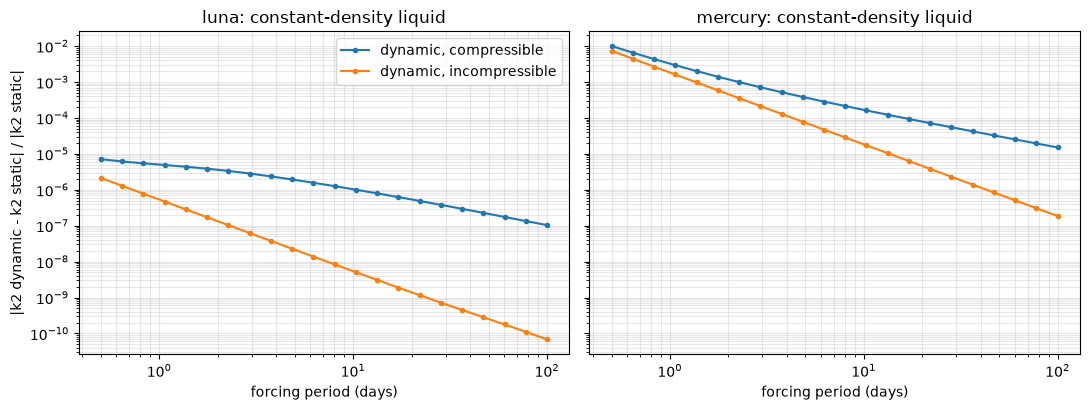

In [2]:
periods = np.logspace(np.log10(0.5), np.log10(100.0), 22)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, name in zip(axes, ("luna", "mercury")):
    world = solved(name)
    curves = {}
    for label, is_static, incompressible in (("static", True, False), ("dynamic, compressible", False, False),
                                             ("dynamic, incompressible", False, True)):
        set_liquids(world, is_static, incompressible)
        curves[label] = love_k(world, periods)
    set_liquids(world, True)
    for label in ("dynamic, compressible", "dynamic, incompressible"):
        diff = np.abs(curves[label] - curves["static"]) / np.abs(curves["static"])
        ax.loglog(periods, diff, "o-", ms=3, label=label)
        failed = periods[np.isnan(diff)]  # NaN where the dynamic solve failed
        failures = f"fails from {failed[0]:.1f} days" if failed.size else "no failures"
        print(f"{name:8} {label:24} difference {diff[0]:.1e} at {periods[0]:.1f} days, {diff[-1]:.1e} at "
              f"{periods[-1]:.0f} days, {failures}")
    ax.set_title(f"{name}: constant-density liquid")
    ax.set_xlabel("forcing period (days)")
    ax.grid(True, which="both", alpha=0.3)
axes[0].set_ylabel("|k2 dynamic - k2 static| / |k2 static|")
axes[0].legend()
plt.tight_layout()
plt.show()

At the shortest periods both dynamic solves differ from the static one because the liquid's inertia matters there, by $7 \times 10^{-6}$ for the Moon's core and $10^{-2}$ for Mercury's at half a day. The differences fall as the period grows, since the static form is the long-period limit of the dynamic one. At 100 days they fall to $10^{-7}$ (compressible) and $7 \times 10^{-11}$ (incompressible) for the Moon, and $1.5 \times 10^{-5}$ and $2 \times 10^{-7}$ for Mercury. No solve fails.

## Stratification and Cost

A liquid is neutrally stratified (buoyancy frequency $N^2 = -g\,(\rho'/\rho + \rho g / K) = 0$) when its density follows its bulk modulus, $\rho' = d\rho/dr = -\rho^2 g / K$. A constant-density liquid with a finite bulk modulus has $N^2 = -\rho g^2 / K < 0$. It is unstably stratified, and its dynamic solutions grow through the layer as $e^E$, with

$$E = \frac{\sqrt{\ell(\ell+1)}}{\omega} \int \frac{\sqrt{-N^2}}{r}\, dr.$$

$E$ is proportional to the forcing period. Re-orthonormalizing the solutions keeps the solve accurate whatever $E$, but the integrator still follows the growth, so its steps grow with the period. A stably stratified liquid ($N^2 > 0$) instead carries internal gravity waves whose wavelength shrinks with the period, with the same cost. A constant-density incompressible liquid has no bulk-modulus term and is neutral. The cell below reads $N^2$ from the solved interior (`buoyancy_frequency_squared` in a solution's `eos_call`) and gives the stratification $S = -N^2 / (\rho g^2 / K)$ (0 for neutral, 1 for constant density) and $E$ for Luna's core and for `luna_dynamic`, whose core follows a Birch-Murnaghan law.

luna          S from +1.00e+00 to +1.00e+00;  E at 1 d: 1.9, 10 d: 19.3, 100 d: 193.3
luna_dynamic  S from +0.00e+00 to +0.00e+00;  E at 1 d: 0.0, 10 d: 0.0, 100 d: 0.0


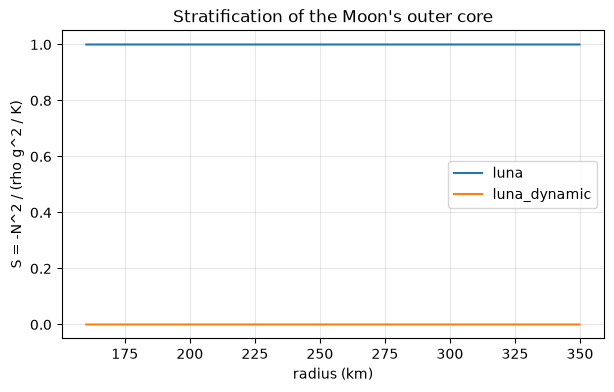

In [3]:
def stratification(world, layer_name, num=2000):
    "S = -N^2 / (rho g^2 / K) through a layer, and E per unit frequency at degree 2."
    world.solve_love_numbers(1.0e-5, 2, warnings=False)
    solution = world.release_radial_solution()
    layer = world[layer_name]
    span = layer.radius_outer - layer.radius_inner
    r = np.linspace(layer.radius_inner + 1e-3 * span, layer.radius_outer - 1e-3 * span, num)
    state = solution.eos_call(r)
    rho, g, K, n2 = (state[key] for key in ("density", "gravity", "bulk_modulus", "buoyancy_frequency_squared"))
    S = -n2 / (rho * g ** 2 / K)
    E_times_omega = math.sqrt(6.0) * trapezoid(np.sqrt(np.maximum(-n2, 0.0)) / r, r)
    return r, S, E_times_omega


fig, ax = plt.subplots(figsize=(7, 4))
luna = solved("luna")
set_liquids(luna, is_static=False)
for name, world in (("luna", luna), ("luna_dynamic", solved("luna_dynamic"))):
    r, S, E_omega = stratification(world, "outer_core")
    ax.plot(r / 1e3, S, label=name)
    growth = ", ".join(f"{p:g} d: {E_omega / (2 * math.pi / (p * DAY)):.1f}" for p in (1, 10, 100))
    print(f"{name:13s} S from {S.min():+.2e} to {S.max():+.2e};  E at {growth}")
ax.set_xlabel("radius (km)")
ax.set_ylabel("S = -N^2 / (rho g^2 / K)")
ax.set_title("Stratification of the Moon's outer core")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Luna's core has $S = 1$ everywhere, and $E$ reaches about 19 at 10 days. The Birch-Murnaghan core has $S = 0$ exactly. TidalPy forms $N^2$ from the material's own density derivatives, so a density that follows the bulk modulus gives zero rather than the roundoff of $\rho'$ against $\rho^2 g / K$.

The cell below counts the core's integration steps from 1 to 1000 days for the three cores and checks each $k_2$ against an `rtol = 1e-11` solve.

In [4]:
cases = (("luna, compressible", "luna", False), ("luna, incompressible", "luna", True),
         ("luna_dynamic", "luna_dynamic", False))
print(f"{'core':22s}" + "".join(f"{p:>14s}" for p in ("1 d", "10 d", "100 d", "1000 d")))
for label, name, incompressible in cases:
    world = solved(name)
    set_liquids(world, False, incompressible)
    cells = []
    for period in (1.0, 10.0, 100.0, 1000.0):
        steps = liquid_steps(world, period)[0]
        k, k_tight = complex(love_k(world, period)), complex(love_k(world, period, rtol=1e-11, atol=1e-11))
        cells.append(f"{steps:6d} ({abs(k - k_tight) / abs(k_tight):.0e})")
    print(f"{label:22s}" + "".join(f"{cell:>14s}" for cell in cells))

core                             1 d          10 d         100 d        1000 d
luna, compressible         9 (3e-11)    27 (1e-11)   270 (2e-11)  2710 (4e-12)
luna, incompressible       8 (2e-11)     8 (2e-11)     8 (2e-11)     8 (7e-12)
luna_dynamic               8 (2e-11)     8 (2e-11)     8 (2e-11)     8 (7e-12)


Each entry is the steps through the core and, in parentheses, the $k_2$ difference from the tight solve. Every core keeps the default tolerance's accuracy. The unstably stratified compressible core's steps grow in proportion to the period, while the two neutral cores' stay at 8.

## Liquids with an Equation of State: the `_dynamic` Worlds

Four bundled worlds solve their liquid dynamically with a pressure-dependent law. `luna_dynamic` and `mercury_dynamic` are refitted to the same observables as their static counterparts, and `pluto_dynamic` has the structure of `pluto`. `europa_dynamic` instead adds an ocean that the bundled `europa` lacks, which raises its $k_2$ at the orbital period from 0.015 to 0.26.

| World | Liquid | Law |
|---|---|---|
| `luna_dynamic` | Fe-S outer core | Birch-Murnaghan, $K$ and $K'$ of Fe80S20 liquid (Nishida et al. 2020) |
| `mercury_dynamic` | Fe-Si outer core | Birch-Murnaghan, $K$ and $K'$ of Margot et al. (2018) |
| `pluto_dynamic` | Liquid zone of an ice Ih hydrosphere, under its solid zone | MatPack's `water`, Birch-Murnaghan from IAPWS |
| `europa_dynamic` | 115 km water ocean under a 25 km shell | Birch-Murnaghan fitted to IAPWS-95 at 273 K |

Below, each world's dynamic $k_2$ is compared with its static $k_2$ from 1 to 1000 days.

luna_dynamic     difference from 4.4e-12 at 1000 days to 5.4e-07, 5.4e-07 at 1 day and 4.4e-12 at 1000 days
mercury_dynamic  difference from 1.8e-09 at 1000 days to 1.9e-03, 1.9e-03 at 1 day and 1.8e-09 at 1000 days
pluto_dynamic    difference from 1.4e-08 at 1000 days to 7.9e-03, 7.9e-03 at 1 day and 1.4e-08 at 1000 days


europa_dynamic   difference from 1.7e-08 at 1000 days to 1.6e-02, 1.6e-02 at 1 day and 1.7e-08 at 1000 days


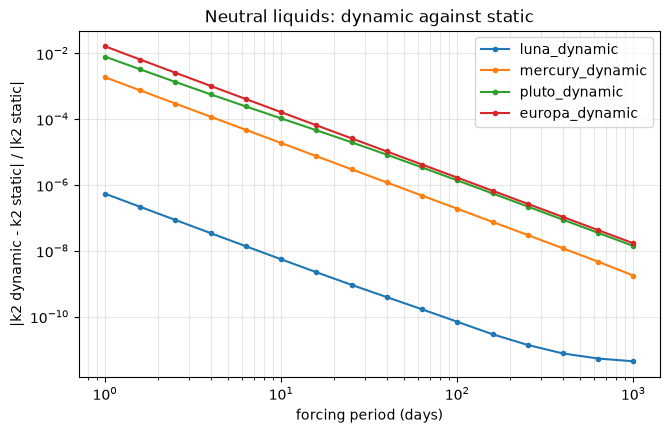

In [5]:
periods = np.logspace(0.0, 3.0, 16)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name in ("luna_dynamic", "mercury_dynamic", "pluto_dynamic", "europa_dynamic"):
    world = solved(name)
    k_dynamic = love_k(world, periods)
    set_liquids(world, is_static=True)
    k_static = love_k(world, periods)
    diff = np.abs(k_dynamic - k_static) / np.abs(k_static)
    ax.loglog(periods, diff, "o-", ms=3, label=name)
    smallest = np.nanargmin(diff)
    print(f"{name:16} difference from {diff[smallest]:.1e} at {periods[smallest]:4.0f} days to {np.nanmax(diff):.1e}, "
          f"{diff[0]:.1e} at 1 day and {diff[-1]:.1e} at 1000 days")
ax.set_xlabel("forcing period (days)")
ax.set_ylabel("|k2 dynamic - k2 static| / |k2 static|")
ax.set_title("Neutral liquids: dynamic against static")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

The dynamic and static solutions differ most at short periods, where inertia matters, and converge as the period grows, to between $4 \times 10^{-12}$ (`luna_dynamic`) and $2 \times 10^{-8}$ (`europa_dynamic`) at 1000 days, since the static form is the long-period limit of a neutral dynamic liquid.

## Tolerances at Long Periods

The dynamic equations recover the tangential displacement $y_3 = -P / (\rho \omega^2 r)$ from a pressure variable $P$ of order $\omega^2$. TidalPy stores $P$ in units of $\omega^2 / (\pi G \bar{\rho})$ of a stress at long periods, so the integration tolerances apply to $y_3$ itself. The cell below compares three tolerances, each with `atol` equal to `rtol` (the default is `3e-8` for both), for `luna_dynamic` against an `rtol = 1e-12` reference, from a month to the $10^{-16}$ rad s$^{-1}$ minimum frequency, with the time per solve.

In [6]:
world = solved("luna_dynamic")
print(f"{'period':>9s} {'rtol, atol':>10s} {'k2 error':>10s} {'time [ms]':>10s}")
for period in (27.3217, 365.25, 1.0e4, 2.0 * math.pi / 1.0e-16 / DAY):
    reference = love_k(world, period, rtol=1e-12, atol=1e-14)
    for tolerance in (1e-6, 3e-8, 1e-9):
        k = love_k(world, period, rtol=tolerance, atol=tolerance)
        seconds = min(timeit.repeat(lambda: love_k(world, period, rtol=tolerance, atol=tolerance), number=3,
                                    repeat=3)) / 3
        print(f"{period:9.3g}d {tolerance:10.0e} {abs(k - reference) / abs(reference):10.1e} {seconds * 1e3:10.2f}")

   period rtol, atol   k2 error  time [ms]


     27.3d      1e-06    5.8e-10       0.27
     27.3d      3e-08    1.8e-11       0.33
     27.3d      1e-09    8.0e-13       0.47
      365d      1e-06    4.0e-10       0.25
      365d      3e-08    1.1e-11       0.35
      365d      1e-09    4.1e-13       0.46
    1e+04d      1e-06    4.3e-10       0.31
    1e+04d      3e-08    1.0e-11       0.33
    1e+04d      1e-09    2.5e-13       0.41


 7.27e+11d      1e-06    5.0e-11       1.12
 7.27e+11d      3e-08    6.5e-13       1.62
 7.27e+11d      1e-09    1.9e-13       2.62


Even `1e-6` gives $k_2$ to better than $10^{-9}$ at every period here, down to the minimum frequency, and a solve takes under 3 ms. The radial functions inside the liquid hold the tolerance too (see the [Dense Radial Solutions](../../Documentation/RadialSolver/dense_radial_solution.md) documentation).

## Summary

| Liquid | Static | Dynamic |
|---|---|---|
| Constant density, compressible (most shipped liquids) | Accurate at every period | Unstably stratified. Accurate, with steps that grow in proportion to the period. |
| Constant density, incompressible | Accurate | Neutral |
| Pressure-dependent law (the `_dynamic` worlds) | Accurate | Neutral |

Use a static liquid for long-period tides, which is the cheapest choice at any density profile. Use a dynamic one when inertia matters (short periods, ocean resonances). A neutral density profile, one that follows the bulk modulus or a constant density in an incompressible liquid, keeps its long-period cost flat.